In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
xMin = 1.2345
xMax = 2.3445
nn = 17
x = np.zeros(nn)
for i in range(nn):
    x[i] = xMin + (xMax - xMin) * i / (nn - 1)

print(x)

[1.2345   1.303875 1.37325  1.442625 1.512    1.581375 1.65075  1.720125
 1.7895   1.858875 1.92825  1.997625 2.067    2.136375 2.20575  2.275125
 2.3445  ]


In [3]:
H = np.loadtxt('topography_180x360_grid.txt')   
latitude, longitude = H.shape                  

R = 6378.0                                      
dtheta = np.pi / latitude                     
dphi   = 2*np.pi / longitude  

thetaA = 0.0
for i in range(latitude):
    theta = i * dtheta
    phiA = 0.0
    for j in range(longitude):
        phiA += np.sum(dphi)
    thetaA += np.sum(np.sin(theta) * dtheta * phiA)
area = (R**2) * thetaA

waterA = 0.0
for i in range(latitude):
    theta = i * dtheta
    phiA = 0.0
    for j in range(longitude):
        if H[i, j] < 0:
            phiA += np.sum(dphi)
    waterA += np.sum(np.sin(theta) * dtheta * phiA)
water_area = (R**2) * waterA

ocean_volume = 0.0
for i in range(latitude):
    theta = i * dtheta
    for j in range(longitude):
        if H[i,j] < 0:  
            cell_area = (R**2) * np.sin(theta) * dtheta * dphi
            ocean_volume += -H[i,j] * cell_area   

oceanV = ocean_volume * 1e6  
fraction_water = water_area / area


print(f"Area of the earth is {area} km^2")
print(f"Area of earth that is water is {water_area} km^2")
print(f"The volume of the ocean is {oceanV} m^3")
print(f"The fraction of the earth that is water is {fraction_water}")


Area of the earth is 511172956.1116579 km^2
Area of earth that is water is 362764094.0877439 km^2
The volume of the ocean is 1.3414813596593759e+18 m^3
The fraction of the earth that is water is 0.7096699654206738


In [4]:
oceanV1 = 0
for i in range(latitude):
    theta = i * dtheta
    for j in range(longitude):
        if H[i,j] < 0:
            cell_area = (R**2) * np.sin(theta) * dtheta * dphi
            depth = (-H[i,j]) - 425.0
            if depth > 0:
                oceanV1 += depth * cell_area

oceanV1_m3 = oceanV1 * 1e6
decrease1 = (oceanV - oceanV1_m3) / oceanV * 100.0

print(f"New ocean volume is {oceanV1_m3} m^3")
print(f"Percentage decrease is {decrease1}%")


New ocean volume is 1.19590978828734e+18 m^3
Percentage decrease is 10.851553793412295%


In [5]:
ocean_area2 = 0.0
for i in range(latitude):
    theta = i * dtheta
    for j in range(longitude):
        if H[i, j] < 625:
            cell_area = (R**2) * np.sin(theta) * dtheta * dphi
            ocean_area2 += cell_area

fraction_ocean2 = ocean_area2 / area * 100.0

print(f"New ocean-covered area is {ocean_area2} km^2")
print(f"Fraction of Earth’s surface covered by oceans is {fraction_ocean2}%")


New ocean-covered area is 453869308.9198922 km^2
Fraction of Earth’s surface covered by oceans is 88.78977330341228%


In [6]:
target_increase = 5.5

for dh in range(0, 401, 2):
    oceanV_test = 0.0
    for i in range(latitude):
        theta = i * dtheta
        for j in range(longitude):
            if H[i, j] < dh:
                cell_area = (R**2) * np.sin(theta) * dtheta * dphi
                depth = dh - H[i, j]
                oceanV_test += depth * cell_area
    oceanV_test *= 1e6

    increase = (oceanV_test - oceanV) / oceanV * 100.0
    if increase >= target_increase:
        print(f"Sea level rise about {dh} m")
        print(f"New ocean volume is {oceanV_test} m^3")
        print(f"Increase = {increase}%")
        break


Sea level rise about 194 m
New ocean volume is 1.4155322706715313e+18 m^3
Increase = 5.520084977621913%


In [7]:
lat_min = 33;
lat_max = 42;
lon_min = -125;
lon_max = -115;

In [8]:
CAC = np.loadtxt('CA_coast_line_no_islands.txt', usecols=(0,1)) 
CAB = np.loadtxt('CA_boundary2.txt', usecols=(0,1)) 
print(CAC.shape,CAB.shape)

(1282, 2) (1295, 2)


In [9]:
CAC1 = np.append( CAC,  [[lon_min,max(CAC[:,1])]],axis=0)
CAC2 = np.append( CAC1, [[lon_min,min(CAC[:,1])]],axis=0)
ocean = CAC2.copy()

In [10]:
plate = np.loadtxt('plate.txt', usecols=(0,1)) 
print(plate.shape)

(925, 2)


In [11]:
#lat_UCB = 37+52/60+19.54/3600;
#lat_LAX = 33+56/60+38.89/3600;
lat_LAX = 33.9416
lon_LAX = -118.4085
lat_UCB = 37.8716
lon_UCB = -122.2727

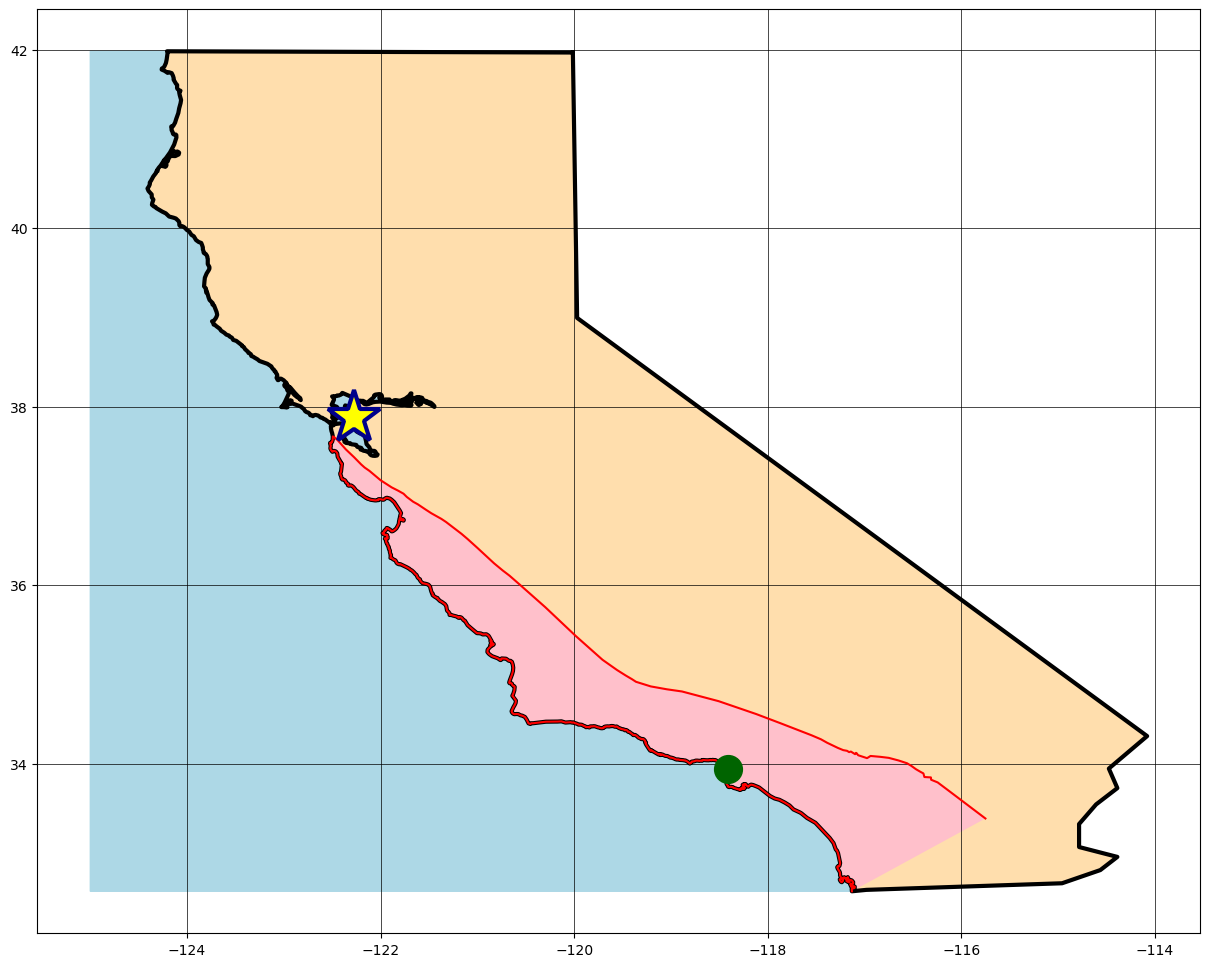

In [12]:
plt.rcParams['figure.figsize'] = [15, 12]

plt.plot(CAB[:,0],CAB[:,1],'k-',lw=3)
plt.fill(CAB[:,0],CAB[:,1],'navajowhite') 

#plt.fill(land[:,0],land[:,1],'-',color='lightgrey')
plt.fill(ocean[:,0],ocean[:,1],'-',color='lightblue')

plt.plot(plate[:,0],plate[:,1],'r-')
plt.fill(plate[:,0],plate[:,1],'pink')

plt.plot(lon_LAX,lat_LAX,'o',color='darkgreen',ms=20)
plt.plot(lon_UCB,lat_UCB,'*',mec='darkblue',mew=3,mfc='yellow',ms=40)

plt.grid(color='k', linestyle='-', linewidth=0.5)
plt.show()

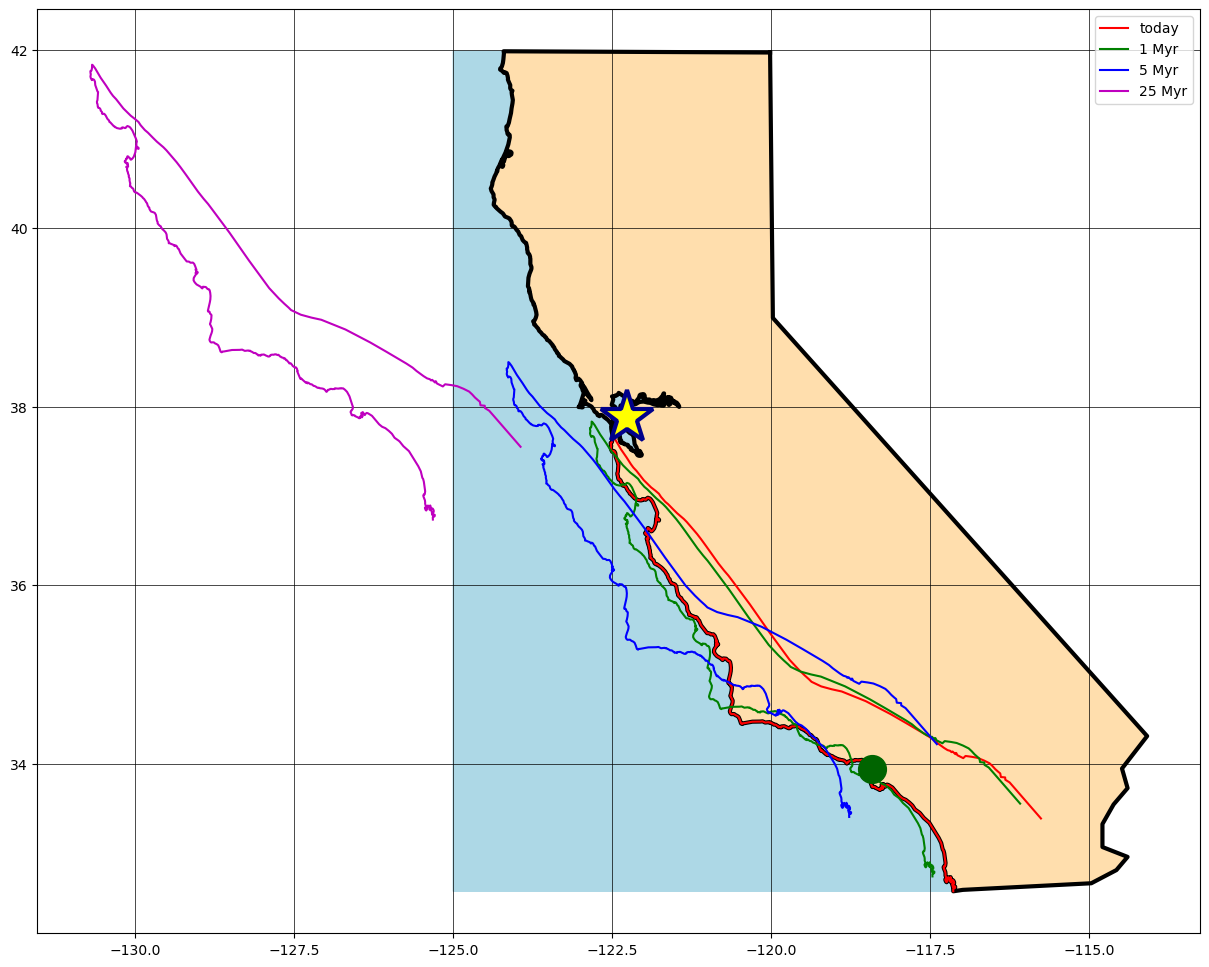

In [13]:
speed_km_per_Myr = 35.0
angle = np.deg2rad(32.0)

km_per_deg_lat = 2*np.pi*R/360.0
km_per_deg_lon = (np.pi*R*np.cos(np.deg2rad(35.5)))/180.0

# 1 Myr
dx = speed_km_per_Myr*1*np.cos(angle)
dy = speed_km_per_Myr*1*np.sin(angle)
dlon = -dx/km_per_deg_lon
dlat =  dy/km_per_deg_lat
plate_1 = plate.copy()
plate_1[:,0] += dlon
plate_1[:,1] += dlat

# 5 Myr
dx = speed_km_per_Myr*5*np.cos(angle)
dy = speed_km_per_Myr*5*np.sin(angle)
dlon = -dx/km_per_deg_lon
dlat =  dy/km_per_deg_lat
plate_5 = plate.copy()
plate_5[:,0] += dlon
plate_5[:,1] += dlat

# 25 Myr
dx = speed_km_per_Myr*25*np.cos(angle)
dy = speed_km_per_Myr*25*np.sin(angle)
dlon = -dx/km_per_deg_lon
dlat =  dy/km_per_deg_lat
plate_25 = plate.copy()
plate_25[:,0] += dlon
plate_25[:,1] += dlat


plt.rcParams['figure.figsize'] = [15, 12]

plt.plot(CAB[:,0], CAB[:,1], 'k-', lw=3)
plt.fill(CAB[:,0], CAB[:,1], 'navajowhite')
plt.fill(ocean[:,0], ocean[:,1], '-', color='lightblue')

plt.plot(plate[:,0],   plate[:,1],   'r-', label='today')
plt.plot(plate_1[:,0], plate_1[:,1], 'g-', label='1 Myr')
plt.plot(plate_5[:,0], plate_5[:,1], 'b-', label='5 Myr')
plt.plot(plate_25[:,0],plate_25[:,1],'m-', label='25 Myr')

plt.plot(lon_LAX, lat_LAX, 'o', color='darkgreen', ms=20)
plt.plot(lon_UCB, lat_UCB, '*', mec='darkblue', mew=3, mfc='yellow', ms=40)

plt.grid(color='k', linestyle='-', linewidth=0.5)
plt.legend()
plt.show()

In [14]:
north_km_per_Myr = speed_km_per_Myr*np.sin(angle)
deg_lat_per_Myr  = north_km_per_Myr / km_per_deg_lat

T_match_Myr = (lat_UCB - lat_LAX) / deg_lat_per_Myr

print(f"Latitude match in about {T_match_Myr} Myr")

Latitude match in about 23.58721581718513 Myr
